In [ ]:
!pip install rasterio
import random
import os
import json
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models,mixed_precision
import tensorflow.keras.backend as K
from rasterio.enums import Resampling
from sklearn.metrics import f1_score, jaccard_score
import scipy.ndimage as ndimage
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, roc_curve, auc
from tensorflow.keras.layers import TimeDistributed,GlobalAveragePooling2D,\
                                    Dense,Conv2D,Input,ConvLSTM2D,LayerNormalization,\
                                    MaxPooling2D,Concatenate,UpSampling2D,Activation,Layer

from tensorflow.keras.models import Model


random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 50.5 MB/s eta 0:00:00:00:0100:01


In [ ]:

def split_data_deterministic(data, train_ratio=0.8, val_ratio=0.10, test_ratio=0.10):
    """
    División determinista de datos usando semilla global
    """
    shuffled_data = data.copy()
    random.shuffle(shuffled_data)
    
    total = len(shuffled_data)
    train_size = int(total * train_ratio)
    val_size = int(total * val_ratio)
    
    train_data = shuffled_data[:train_size]
    val_data = shuffled_data[train_size:train_size + val_size]
    test_data = shuffled_data[train_size + val_size:]
    
    return train_data, val_data, test_data

if not os.path.exists('files.json'):
    train, val, test = split_data_deterministic(list(path_valid))
    r ={}
    r['train']=train
    r['test']=test
    r['val']=val
    with open('files.json','w') as f:
              json.dump(r, f, ensure_ascii=False, indent=4)
else:
    with open('files.json','r') as f:
        data = json.load(f)
    train,val,test = data['train'],data['val'],data['test']

# hyperparámetros


In [ ]:

#Dataset
CROP_SIZE = 256         
INPUT_CHANNELS = 28 
INPUT_SEQ_LEN = 3  
STRIDE_T=1

# Training Hyperparameters
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 100 
DROPOUT = 0.3
INPUT_SHAPE = (BATCH_SIZE,INPUT_SEQ_LEN,INPUT_CHANNELS,CROP_SIZE,CROP_SIZE)
CLIPNORM =1.0
 
#Atention 
REDUCTION=4

# LOSS
GAMMA=2.0
ALPHA = 0.5
SMOOTH = 1.0

#DIR
BASE_CACHE_DIR = 'saved/data_cache'
last_checkpoint_path = 'saved/checkpoints/last_model_convlstm7.weights.h5'
best_checkpoint_path = 'saved/checkpoints/best_fire_model7_convlstm.weights.h5'
history_path = 'training_history7.json'

# Dataset

In [ ]:

class TSDataset:
    def __init__(
        self,
        path_valid,
        cache_dir,
        crop_size=256,
        seq_len=3,
        stride_t=1,
        force_rebuild=False,
    ):
        self.crop_size = crop_size
        self.seq_len = seq_len
        self.stride_t = stride_t
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)

        self.catalog_path = self.cache_dir / f"catalog_flat_s{seq_len}_st{stride_t}_c{crop_size}.json"
        
        self.raw_paths = self._find_tiff_files(path_valid)

        if self.catalog_path.exists() and not force_rebuild:
            print(f"Cargando catálogo plano desde {self.catalog_path}...")
            with open(self.catalog_path, "r") as f:
                self.samples = json.load(f)
        else:
            print("Generando catálogo ...")
            self.samples = self._create_flat_catalog()
            with open(self.catalog_path, "w") as f:
                json.dump(self.samples, f)

        print(f"Dataset listo: {len(self.samples)} muestras.")

    def _find_tiff_files(self, paths):
        r = {}
        for idx, base in enumerate(paths):
            r[idx] = {k: [] for k in ["FirePred", "VIIRS_Day", "VIIRS_Night"]}
            for folder in os.listdir(base):
                p = Path(base, folder)
                if p.is_dir() and folder in r[idx]:
                    r[idx][folder] = sorted(list(p.rglob("*.tif")), key=lambda x: x.name)
        return r

    def _create_flat_catalog(self):
        catalog = []
        for region_idx, folders in tqdm(self.raw_paths.items()):
            num_days = min(
                len(folders["VIIRS_Day"]),
                len(folders["VIIRS_Night"]),
                len(folders["FirePred"]),
            )
            
         
            for t_start in range(0, num_days - self.seq_len, self.stride_t):
                sample_id = f"reg{region_idx}_t{t_start}"
                catalog.append({
                    "region": region_idx,
                    "t_start": t_start,
                    "sample_id": sample_id
                })
        return catalog

    def _normalize(self, x, is_label=False):
        x = np.nan_to_num(x, nan=0.0)
        if is_label:
            return np.clip(x, 0.0, 1.0)
        for c in range(x.shape[0]):
            vmin, vmax = x[c].min(), x[c].max()
            if vmax - vmin > 1e-6:
                x[c] = (x[c] - vmin) / (vmax - vmin)
        return x

    def _load_single_window(self, info):
        region = self.raw_paths[info["region"]]
        t_start = info["t_start"]
        
        seq_x = []

        for t in range(t_start, t_start + self.seq_len):
            #  VIIRS Day
            with rasterio.open(region["VIIRS_Day"][t]) as dsrc:
                y0 = (dsrc.height - self.crop_size) // 2
                x0 = (dsrc.width - self.crop_size) // 2
                win = rasterio.windows.Window(x0, y0, self.crop_size, self.crop_size)
                day = self._normalize(dsrc.read([1,2,3,4,5,6], window=win))
                fire_today = self._normalize(dsrc.read([7], window=win), is_label=True)

            #  VIIRS Night
            with rasterio.open(region["VIIRS_Night"][t]) as nsrc:
                night = self._normalize(nsrc.read( window=win)[-2:])

            #  FirePred
            with rasterio.open(region["FirePred"][t]) as fsrc:
                firep = self._normalize(fsrc.read(window=win))

            x_combined = np.concatenate([day, fire_today, night, firep], axis=0)
            seq_x.append(x_combined)

        # Target
        with rasterio.open(region["VIIRS_Day"][t_start + self.seq_len]) as dsrc:
            y_target = self._normalize(dsrc.read([7], window=win), is_label=True)

        return np.stack(seq_x), y_target

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        info = self.samples[idx]
        cache_f = self.cache_dir / f"{info['sample_id']}.npz"

        try:
            if not cache_f.exists():
                x, y = self._load_single_window(info)
                np.savez_compressed(cache_f, x=x, y=y)
            else:
                data = np.load(cache_f)
                x, y = data["x"], data["y"]
            
            #  [T, C, H, W] -> [T, H, W, C]
            x = np.transpose(x, (0, 2, 3, 1)) 
            # [1, H, W] -> [H, W, 1]
            y = np.transpose(y, (1, 2, 0))
            
            return x.astype(np.float32), y.astype(np.float32)

        except Exception as e:
            print(f"Error en {cache_f}")
            raise 


            

In [ ]:
cache_base = Path(BASE_CACHE_DIR)


train_dataset = TSDataset(
    path_valid=train,
    cache_dir=cache_base/'train',      
    crop_size=CROP_SIZE,
    stride_t=STRIDE_T
       #force_rebuild=True
)

val_dataset = TSDataset(
    path_valid=val,
    cache_dir=cache_base/'val',
    crop_size=CROP_SIZE,
    seq_len =INPUT_SEQ_LEN,
    stride_t=STRIDE_T 
    #force_rebuild=True
)


Cargando catálogo plano desde saved/data_cache/train/catalog_flat_s3_st1_c256.json...
Dataset listo: 1788 muestras independientes.
Cargando catálogo plano desde saved/data_cache/val/catalog_flat_s3_st1_c256.json...
Dataset listo: 284 muestras independientes.


In [ ]:

def prepare_tf_dataset(py_dataset, batch_size=4, is_train=True):
    def generator():
        for i in range(len(py_dataset)):
            yield py_dataset[i]

    # x: (T, H, W, C), y: (H, W, 1)
    output_signature = (
        tf.TensorSpec(shape=(3, 256, 256, 28), dtype=tf.float32), 
        tf.TensorSpec(shape=(256, 256, 1), dtype=tf.float32)
    )

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=output_signature
    )

    if is_train:
        ds = ds.shuffle(buffer_size=100)
    
    ds = ds.batch(batch_size)
    
    ds = ds.prefetch(tf.data.AUTOTUNE).repeat()
    
    return ds


train_tf_ds = prepare_tf_dataset(train_dataset, batch_size=BATCH_SIZE, is_train=True)
val_tf_ds = prepare_tf_dataset(val_dataset, batch_size=BATCH_SIZE, is_train=False)


2026-01-16 11:20:33.197949: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768562433.477981      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768562433.556987      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768562434.200900      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768562434.200978      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768562434.200981      55 computation_placer.cc:177] computation placer alr

Shape de X: (8, 3, 256, 256, 28)


# model 

In [ ]:

class ConvLSTMAttentionBlock(Layer):
    def __init__(self, channels, reduction=4, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

        # Channel attention
        self.avg_pool = TimeDistributed(
            GlobalAveragePooling2D()
        )
        self.fc1 = Dense(channels // reduction, activation='relu')
        self.fc2 = Dense(channels, activation='sigmoid')

        # Spatial attention
        self.spatial_conv = TimeDistributed(
            Conv2D(
                filters=1,
                kernel_size=7,
                padding='same',
                activation='sigmoid'
            )
        )

    def call(self, x):
        # x: (B, T, H, W, C)

        #  Channel Attention 
        c = self.avg_pool(x)              # (B, T, C)
        c = self.fc1(c)                   # (B, T, C//r)
        c = self.fc2(c)                   # (B, T, C)
        c = tf.expand_dims(c, axis=2)     # (B, T, 1, C)
        c = tf.expand_dims(c, axis=2)     # (B, T, 1, 1, C)

        x = x * c

        #  Spatial Attention 
        avg_s = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_s = tf.reduce_max(x, axis=-1, keepdims=True)
        s = tf.concat([avg_s, max_s], axis=-1)

        s = self.spatial_conv(s)          # (B, T, H, W, 1)

        return x * s

def build_convlstm_bottleneck128(
    input_shape=(3, 256, 256, 28),
    dropout=0.3,
    reduction=4
):
    inputs = Input(shape=input_shape)

    #  ENCODER 
    e1 = ConvLSTM2D(
        24, 3, padding='same',
        return_sequences=True,
        dropout=dropout,
    )(inputs)
    e1 = LayerNormalization()(e1)

    p1 = TimeDistributed(MaxPooling2D(2))(e1)

    e2 = ConvLSTM2D(
        48, 3, padding='same',
        return_sequences=True,
        dropout=dropout
    )(p1)
    e2 = LayerNormalization()(e2)

    p2 = TimeDistributed(MaxPooling2D(2))(e2)

    e3 = ConvLSTM2D(
        96, 3, padding='same',
        return_sequences=True,
        dropout=dropout
    )(p2)
    e3 = LayerNormalization()(e3)

    #  BOTTLENECK 
    p3 = TimeDistributed(MaxPooling2D(2))(e3)

    b = ConvLSTM2D(
        128, 3, padding='same',
        return_sequences=True,
        dropout=dropout
    )(p3)
    b = LayerNormalization()(b)
    b = ConvLSTMAttentionBlock(128,reduction=reduction)(b)

    #  DECODER 
    u3 = TimeDistributed(UpSampling2D(2))(b)
    u3 = Concatenate(axis=-1)([u3, e3])
    u3 = ConvLSTM2D(96, 3, padding='same', return_sequences=True)(u3)

    u2 = TimeDistributed(UpSampling2D(2))(u3)
    u2 = Concatenate(axis=-1)([u2, e2])
    u2 = ConvLSTM2D(48, 3, padding='same', return_sequences=True)(u2)
    u2 = ConvLSTMAttentionBlock(48,reduction=reduction)(u2)

    u1 = TimeDistributed(UpSampling2D(2))(u2)
    u1 = Concatenate(axis=-1)([u1, e1])
    u1 = ConvLSTM2D(24, 3, padding='same', return_sequences=True)(u1)
    u1 = ConvLSTMAttentionBlock(24,reduction=reduction)(u1)

    # OUTPUT 
    x = ConvLSTM2D(
        16, 3, padding='same',
        return_sequences=False
    )(u1)

    out = Conv2D(1, 1, padding='same')(x)
    out = Activation('linear', dtype='float32', name='predictions')(out)

    return Model(inputs, out, name="ConvLSTM_UNet_Att128")


In [ ]:
build_convlstm_bottleneck128(dropout=DROPOUT).summary()

Model: "ConvLSTM_UNet_Att128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 3, 256,    │          0 │ -                 │
│ (InputLayer)        │ 256, 28)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_40      │ (None, 3, 256,    │     45,024 │ input_layer_5[0]… │
│ (ConvLSTM2D)        │ 256, 24)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 3, 256,    │         48 │ conv_lstm2d_40[0… │
│ (LayerNormalizatio… │ 256, 24)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_60 │ (None, 3, 128,    │          0 │ layer_normalizat… │
│ (TimeDistributed)   │ 128, 24)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_41      │ (None, 3, 128,    │    124,608 │ time_distributed… │
│ (ConvLSTM2D)        │ 128, 48)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 3, 128,    │         96 │ conv_lstm2d_41[0… │
│ (LayerNormalizatio… │ 128, 48)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_61 │ (None, 3, 64, 64, │          0 │ layer_normalizat… │
│ (TimeDistributed)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_42      │ (None, 3, 64, 64, │    498,048 │ time_distributed… │
│ (ConvLSTM2D)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 3, 64, 64, │        192 │ conv_lstm2d_42[0… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_62 │ (None, 3, 32, 32, │          0 │ layer_normalizat… │
│ (TimeDistributed)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_43      │ (None, 3, 32, 32, │  1,032,704 │ time_distributed… │
│ (ConvLSTM2D)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 3, 32, 32, │        256 │ conv_lstm2d_43[0… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm_attentio… │ (None, 3, 32, 32, │      8,451 │ layer_normalizat… │
│ (ConvLSTMAttention… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_65 │ (None, 3, 64, 64, │          0 │ conv_lstm_attent… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_15      │ (None, 3, 64, 64, │          0 │ time_distributed… │
│ (Concatenate)       │ 224)              │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_44      │ (None, 3, 64, 64, │  1,106,304 │ concatenate_15[0… │
│ (ConvLSTM2D)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_66 │ (None, 3, 128,    │          0 │ conv_lstm2d_44[0

 Total params: 3,255,588 (12.42 MB)

 Trainable params: 3,255,588 (12.42 MB)

 Non-trainable params: 0 (0.00 B)

# LOSS

In [ ]:

class FocalDiceLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, smooth=1.0, name="focal_dice_loss"):
        super().__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha
        self.smooth = smooth

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        y_true_tol = tf.nn.max_pool2d(y_true, ksize=5, strides=1, padding='SAME')

        y_pred_prob = tf.nn.sigmoid(y_pred)
        eps = tf.keras.backend.epsilon()
        y_pred_prob = tf.clip_by_value(y_pred_prob, eps, 1.0 - eps)

   
        focal_pos = -self.alpha * tf.pow(1 - y_pred_prob, self.gamma) * tf.math.log(y_pred_prob)
        focal_neg = -(1 - self.alpha) * tf.pow(y_pred_prob, self.gamma) * tf.math.log(1 - y_pred_prob)

        focal = y_true * focal_pos + (1 - y_true_tol) * focal_neg
        focal_loss = tf.reduce_mean(focal)

        y_true_f = tf.reshape(y_true, [-1])
        y_true_tol_f = tf.reshape(y_true_tol, [-1])
        y_pred_f = tf.reshape(y_pred_prob, [-1])

        tp = tf.reduce_sum(y_true_f * y_pred_f)
        fn = tf.reduce_sum(y_true_f * (1 - y_pred_f))
        fp = tf.reduce_sum((1 - y_true_tol_f) * y_pred_f)

        dice = (2 * tp + self.smooth) / (2 * tp + fn + fp + self.smooth)
        dice_loss = 1 - dice

        return 0.5 * focal_loss + 1.5 * dice_loss


# Callback

In [ ]:
class SaveHistoryCallback(tf.keras.callbacks.Callback):
    def __init__(self, filepath):
        super().__init__()
        self.filepath = filepath
        self.history_dict = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = float(self.model.optimizer.learning_rate.numpy())

        current_logs = {
            "epoch": epoch + 1,
            "lr": lr,
        **{k: float(v) for k, v in logs.items()}}
        self.history_dict.append(current_logs)
        
        with open(self.filepath, 'w') as f:
            json.dump(self.history_dict, f, indent=4)

class VisualVerifyCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, save_dir='visual_logs'):
        super().__init__()
        self.dataset = dataset
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        # Tomar un batch de validación
        for inputs, targets in self.dataset.take(1):
            preds = self.model.predict(inputs, verbose=0)
            preds = tf.nn.sigmoid(preds).numpy()
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Frame de entrada (Canal 0 del último paso temporal)
            axes[0].imshow(inputs[0, -1, :, :, 0], cmap='viridis')
            axes[0].set_title("Input (Last Frame)")
            
            # Máscara Real
            axes[1].imshow(targets[0, :, :, 0], cmap='inferno')
            axes[1].set_title("Ground Truth")
            
            # Predicción
            axes[2].imshow(preds[0, :, :, 0], cmap='inferno')
            axes[2].set_title(f"Prediction (Epoch {epoch+1})")
            
            for ax in axes: ax.axis('off')
            
            plt.savefig(f"{self.save_dir}/epoch_{epoch+1}.png")
            plt.close()



# Metric

In [ ]:
class TolerantRecall(tf.keras.metrics.Metric):
    def __init__(self, tol_ksize=5, threshold=0.5, name="tolerant_recall", **kwargs):
        super().__init__(name=name, **kwargs)
        self.tol_ksize = tol_ksize
        self.threshold = threshold
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.nn.sigmoid(y_pred)
        y_pred_bin = tf.cast(y_pred > self.threshold, tf.float32)

        tp = tf.reduce_sum(y_pred_bin * y_true)
        y_pred_tol = tf.nn.max_pool2d(y_pred_bin, ksize=self.tol_ksize, strides=1, padding='SAME')
        fn = tf.reduce_sum(y_true * (1.0 - y_pred_tol))

        self.tp.assign_add(tp)
        self.fn.assign_add(fn)

    def result(self):
        return self.tp / (self.tp + self.fn + tf.keras.backend.epsilon())

    def reset_state(self):
        self.tp.assign(0.0)
        self.fn.assign(0.0)



class TolerantFalseNegatives(tf.keras.metrics.Metric):
    def __init__(self, tol_ksize=5, threshold=0.5, name="tolerant_fn", **kwargs):
        super().__init__(name=name, **kwargs)
        self.tol_ksize = tol_ksize
        self.threshold = threshold

        self.fn = self.add_weight(name="fn", initializer="zeros", dtype=tf.float32)
        self.pos = self.add_weight(name="pos", initializer="zeros", dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)


        y_pred_bin = tf.cast(tf.nn.sigmoid(y_pred) > self.threshold, tf.float32)

        y_pred_tol = tf.nn.max_pool2d(
            y_pred_bin,
            ksize=self.tol_ksize,
            strides=1,
            padding='SAME'
        )

        fn = tf.reduce_sum(y_true * (1.0 - y_pred_tol))
        pos = tf.reduce_sum(y_true)

        self.fn.assign_add(fn)
        self.pos.assign_add(pos)

    def result(self):
        return self.fn / (self.pos + tf.keras.backend.epsilon())

    def reset_state(self):
        self.fn.assign(0.0)
        self.pos.assign(0.0)

            
class TolerantF1Score(tf.keras.metrics.Metric):
    def __init__(self, tol_ksize=5, threshold=0.5, name="tolerant_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.tol_ksize = tol_ksize
        self.threshold = threshold
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fp = self.add_weight(name="fp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin = tf.cast(tf.nn.sigmoid(y_pred) > self.threshold, tf.float32)
        
        y_true_tol = tf.nn.max_pool2d(y_true, ksize=self.tol_ksize, strides=1, padding='SAME')
   
        y_pred_tol = tf.nn.max_pool2d(y_pred_bin, ksize=self.tol_ksize, strides=1, padding='SAME')

        tp = tf.reduce_sum(y_pred_bin * y_true)
        fp = tf.reduce_sum(y_pred_bin * (1.0 - y_true_tol))
        fn = tf.reduce_sum(y_true * (1.0 - y_pred_tol))

        self.tp.assign_add(tp)
        self.fp.assign_add(fp)
        self.fn.assign_add(fn)

    def result(self):
        precision = self.tp / (self.tp + self.fp + tf.keras.backend.epsilon())
        recall = self.tp / (self.tp + self.fn + tf.keras.backend.epsilon())
        
        f1 = 2 * ((precision * recall) / (precision + recall + tf.keras.backend.epsilon()))
        return f1

    def reset_state(self):
        self.tp.assign(0.0)
        self.fp.assign(0.0)
        self.fn.assign(0.0)
      

In [ ]:

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Compute dtype: ',policy.compute_dtype)
print('Variable dtype: ',policy.variable_dtype)


def main():
    os.makedirs('saved/checkpoints', exist_ok=True)

    # Metricas
    metrics = [
        TolerantRecall(name="tol_recall"),
        TolerantFalseNegatives(name="tol_fn"),
        TolerantF1Score(name="f1_score"), 
        tf.keras.metrics.BinaryIoU(target_class_ids=[1], name="iou"), 
        tf.keras.metrics.Precision(name="precision")
    ]


    model = build_convlstm_bottleneck128(input_shape=INPUT_SHAPE,dropout=DROPOUT,reduction=REDUCTION)

    initial_epoch = 0
    best_val_f1 = -1.0 
    history_cb = SaveHistoryCallback(history_path)

    if os.path.exists(history_path):
        try:
            with open(history_path, 'r') as f:
                saved_history = json.load(f)
                history_cb.history_dict = saved_history
                if saved_history:
                    initial_epoch = saved_history[-1]['epoch']
                    f1_values = [h.get('val_f1_score', -1.0) for h in saved_history]
                    best_val_f1 = max(f1_values)
                    print(f"[*] Historial cargado. Reanudando en época {initial_epoch + 1}")
                    print(f"[*] Mejor val_f1 histórico: {best_val_f1:.4f}")
        except Exception as e:
            print(f"[!] Error cargando historial: {e}")

    if os.path.exists(last_checkpoint_path):
        print(f"[*] Cargando pesos recientes: {last_checkpoint_path}")
        model.load_weights(last_checkpoint_path)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=CLIPNORM),
        loss=FocalDiceLoss(gamma=GAMMA,alpha=ALPHA,smooth=SMOOTH),
        metrics=metrics
    )


    best_ckpt_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=best_checkpoint_path,
        monitor='val_f1_score', 
        mode='max',            
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    if best_val_f1 != -1.0:
        best_ckpt_callback.best = best_val_f1

    callbacks = [
        best_ckpt_callback,
        history_cb,
        VisualVerifyCallback(val_tf_ds),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=last_checkpoint_path,
            save_best_only=False,
            save_weights_only=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]

    print(f"\nIniciando entrenamiento")

    steps_per_epoch = len(train_dataset) // BATCH_SIZE
    validation_steps = len(val_dataset) // BATCH_SIZE
    
    model.fit(
        train_tf_ds,
        steps_per_epoch=steps_per_epoch,     
        validation_data=val_tf_ds,
        validation_steps=validation_steps,   
        epochs=epochs,
        initial_epoch=initial_epoch,
        callbacks=callbacks
    )

Compute dtype:  float16
Variable dtype:  float32


In [ ]:
main()


[*] Historial cargado. Reanudando en época 36
[*] Mejor val_f1 histórico: 0.6090
[*] Cargando pesos recientes: saved/checkpoints/last_model_convlstm7.weights.h5

Iniciando entrenamiento: Pure ConvLSTM + Aggressive Loss
Epoch 36/200
148/223 ━━━━━━━━━━━━━━━━━━━━ 1:01 814ms/step - f1_score: 0.7264 - iou: 0.3593 - loss: 0.1692 - precision: 0.4647 - tol_fn: 0.2789 - tol_recall: 0.6887

# eval

In [ ]:

df = pd.read_json('/kaggle/working/training_history7.json')

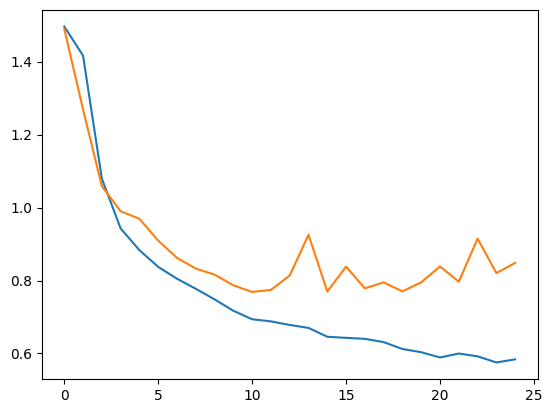

In [4]:
plt.plot(df['loss'][:25])
plt.plot(df['val_loss'][:25])
plt.savefig('fig7')

In [ ]:

class InferenceTS(TSDataset):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.target_size = 512
        self.patch_size = 256

    def _read_and_rescale(self, dataset, bands, window=None, is_label=False):
        """
        Lee y reescala una imagen a 512x512.
        """
        resampling_mode = Resampling.nearest if is_label else Resampling.bilinear
        
        data = dataset.read(
            bands,
            out_shape=(len(bands) if bands else dataset.count, self.target_size, self.target_size),
            resampling=resampling_mode
        )
        return self._normalize(data, is_label=is_label)

    def __getitem__(self, idx):
        info = self.samples[idx]
        region = self.raw_paths[info["region"]]
        t_start = info["t_start"]

        full_seq_512 = [] 
        
        for t in range(t_start, t_start + self.seq_len):
            # VIIRS Day 
            with rasterio.open(region["VIIRS_Day"][t]) as dsrc:
                day = self._read_and_rescale(dsrc, [1, 2, 3, 4, 5, 6])
                fire_today = self._read_and_rescale(dsrc, [7], is_label=True)

            # VIIRS Night
            with rasterio.open(region["VIIRS_Night"][t]) as nsrc:
               
                num_bands = nsrc.count
                night = self._read_and_rescale(nsrc, [num_bands-1, num_bands])

            # FirePred
            with rasterio.open(region["FirePred"][t]) as fsrc:
                firep = self._read_and_rescale(fsrc, None)

            combined_t = np.concatenate([day, fire_today, night, firep], axis=0)
            full_seq_512.append(combined_t)

        # Convertir a tensor
        full_seq_tensor = np.stack(full_seq_512)

        # Dividir en 4 parches de 256x256
        patches = []
        # Cuadrantes: Top-Left, Top-Right, Bottom-Left, Bottom-Right
        offsets = [(0, 0), (0, 256), (256, 0), (256, 256)]
        
        for (y, x) in offsets:
            patch = full_seq_tensor[:, :, y:y+256, x:x+256]
            patches.append(patch)

        return {
            "patches": np.stack(patches), # [4, T, C, 256, 256]
            "sample_id": info['sample_id']
        }

    def predict_full_image(self, model, patches_tensor):
        """
        Predice los 4 parches y los une. 
        """
        patches_np = patches_tensor
        patches_tf = np.transpose(patches_np, (0, 1, 3, 4, 2))
        
        preds = []
        for i in range(4):
            patch = patches_tf[i:i+1] # Shape: (1, T, 256, 256, C)
            
            # (1, 256, 256, 1)
            p = model.predict(patch, verbose=0)
        
            p_prob = tf.nn.sigmoid(p).numpy()
            preds.append(np.squeeze(p_prob))

        # Reconstrucción 2x2 para formar la imagen de 512x512
        top = np.concatenate([preds[0], preds[1]], axis=1)
        bottom = np.concatenate([preds[2], preds[3]], axis=1)
        return np.concatenate([top, bottom], axis=0) # [512, 512]

    def get_ground_truth(self, idx):
        """Extrae el target real de 512x512 reescalado correctamente"""
        info = self.samples[idx]
        region = self.raw_paths[info["region"]]
        t_target = info["t_start"] + self.seq_len
        
        with rasterio.open(region["VIIRS_Day"][t_target]) as dsrc:
            
            y_true = dsrc.read(
                7, 
                out_shape=(self.target_size, self.target_size), 
                resampling=Resampling.nearest
            )
            return self._normalize(y_true, is_label=True)

    def evaluate_tolerantly(self, y_true, y_pred_prob, tol_ksize=5, threshold=0.5):
        """
        Calcula F1 y Recall usando la misma lógica de tolerancia que el entrenamiento.
        y_true: [512, 512]
        y_pred_prob: [512, 512] (probabilidades 0-1)
        """
        # Convertir a tensores de 4D para pooling [Batch, H, W, Channels]
        y_true_t = tf.cast(y_true[np.newaxis, ..., np.newaxis], tf.float32)
        y_pred_t = tf.cast(y_pred_prob[np.newaxis, ..., np.newaxis], tf.float32)
        
        y_pred_bin = tf.cast(y_pred_t > threshold, tf.float32)

        # Crear máscara de tolerancia 
        y_true_tol = tf.nn.max_pool2d(
            y_true_t, ksize=tol_ksize, strides=1, padding='SAME'
        )

        #  Métricas Tolerantes 
        # True Positives correcta dentro de zona tolerante
        tp = tf.reduce_sum(y_pred_bin * y_true_tol)
        
        # False Positives Fuera de la zona de tolerancia
        fp = tf.reduce_sum(y_pred_bin * (1.0 - y_true_tol))
        
        # False Negatives
        y_pred_tol = tf.nn.max_pool2d(y_pred_bin, ksize=tol_ksize, strides=1, padding='SAME')
        fn = tf.reduce_sum(y_true_t * (1.0 - y_pred_tol))

        # Cálculos finales
        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-7)

        return {
            "f1_tolerant": f1.numpy(),
            "recall_tolerant": recall.numpy(),
            "precision_tolerant": precision.numpy()
        }


[*] Pesos cargados correctamente desde saved/checkpoints/best_fire_model7_convlstm.weights.h5
Cargando catálogo plano desde saved/data_cache/test/catalog_flat_s3_st1_c256.json...
Dataset listo: 227 muestras independientes.
Iniciando Inferencia Completa en 227 muestras...


100%|██████████| 227/227 [06:39<00:00,  1.76s/it]


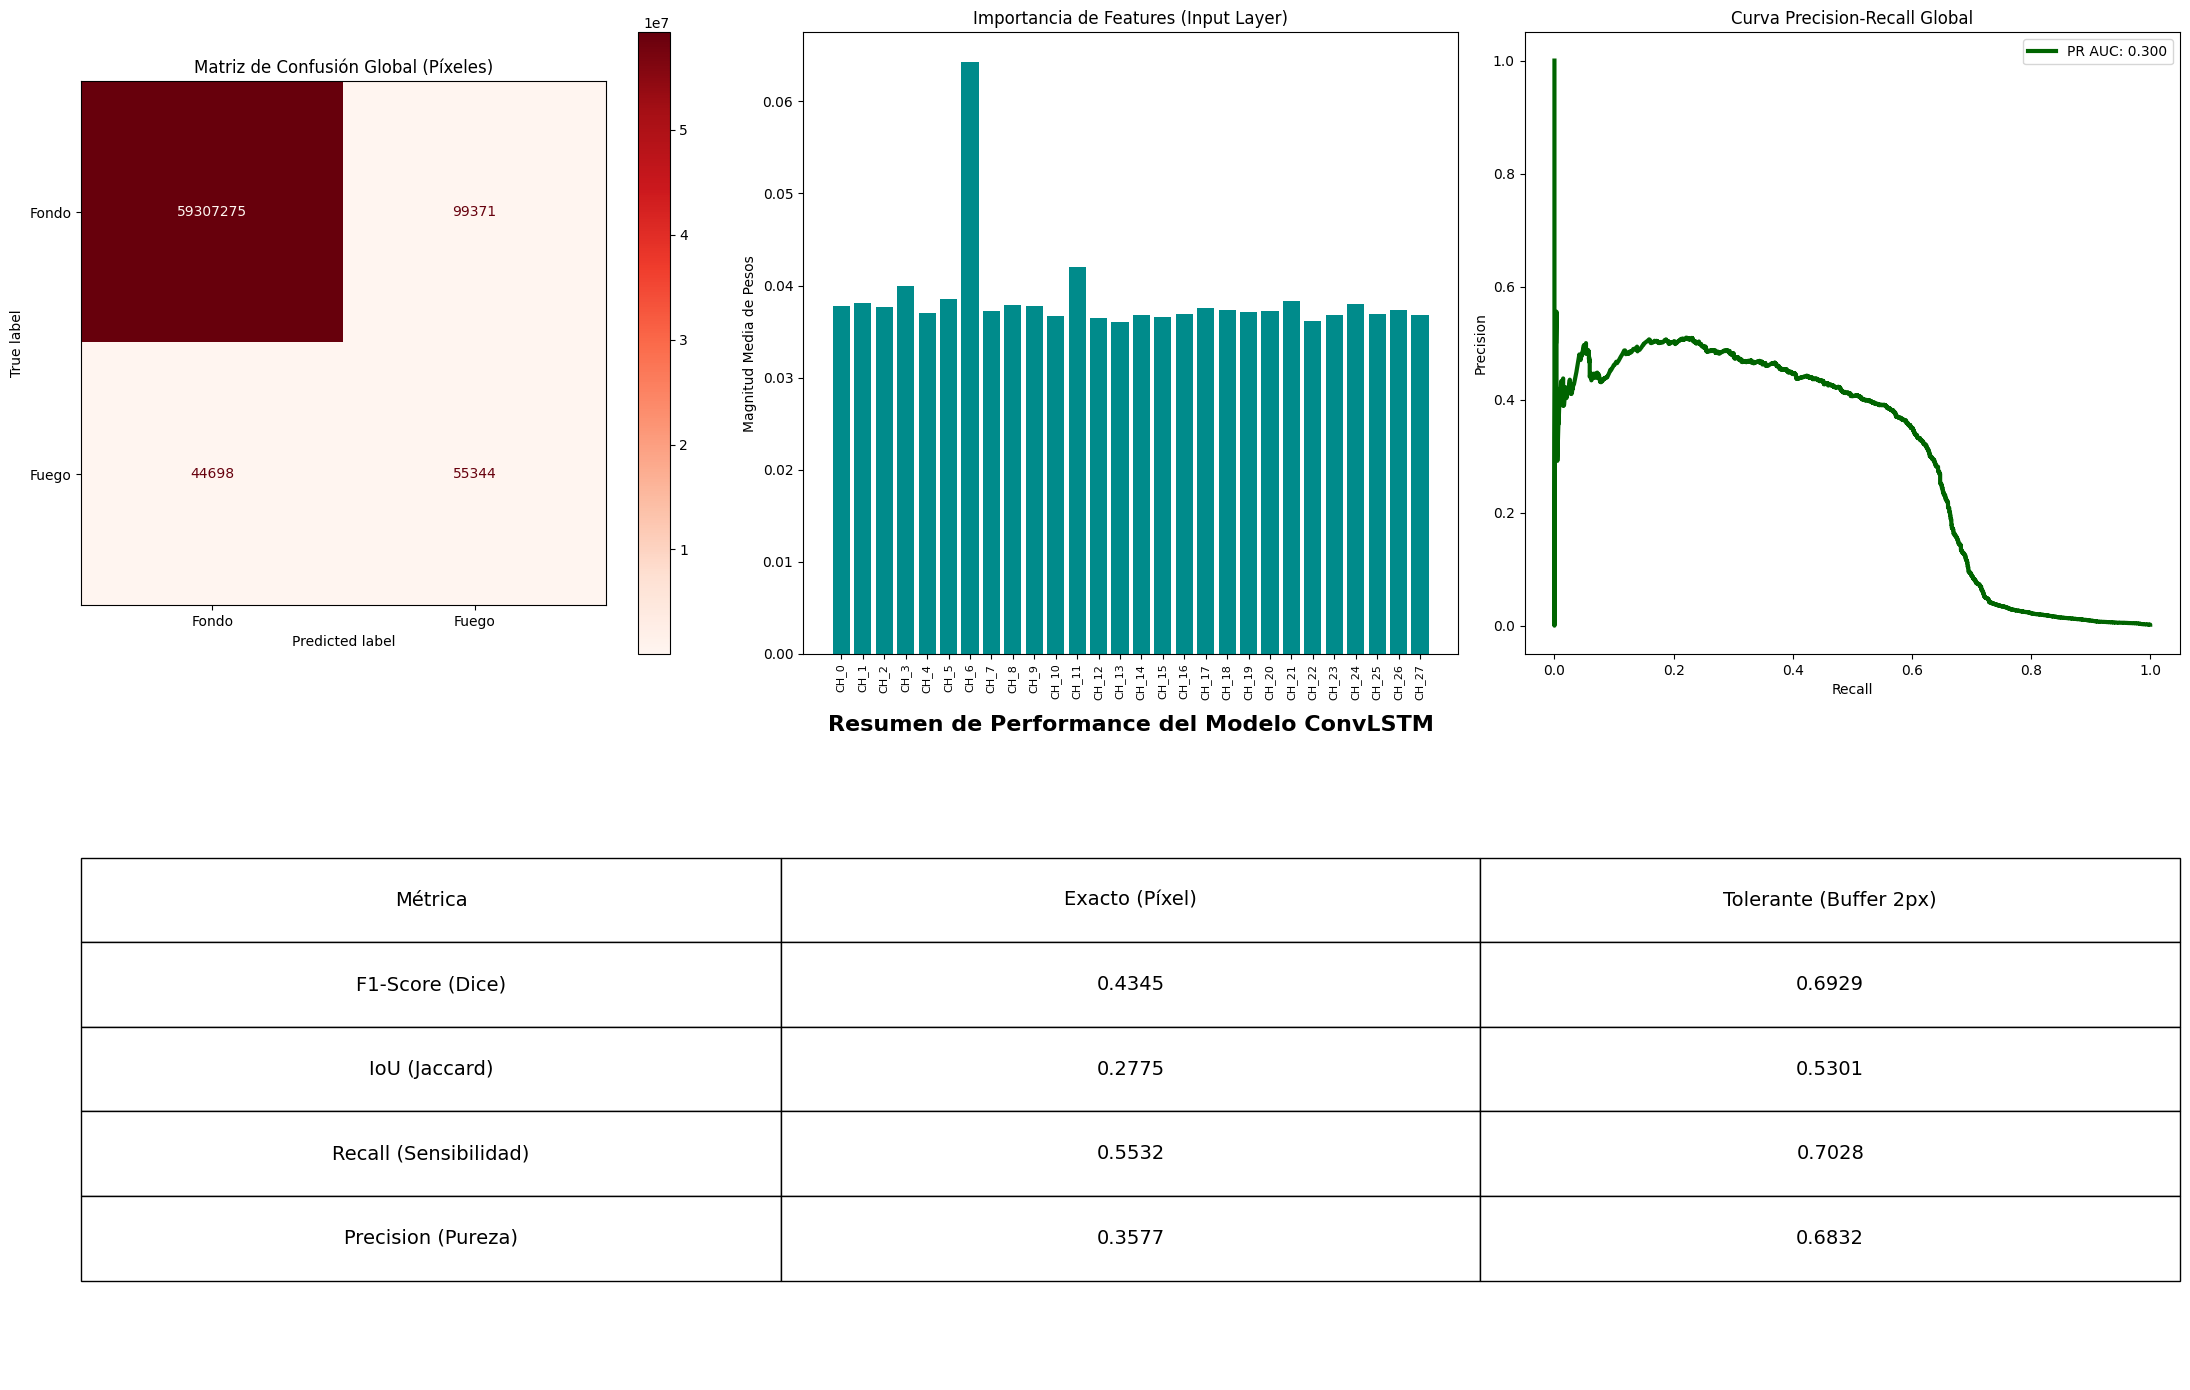

In [ ]:


def get_tolerant_labels(y_true, pixels=2):
    """Dilata las etiquetas reales para permitir un margen de error espacial (Buffer)."""
    struct = ndimage.generate_binary_structure(2, 1)
    struct = ndimage.iterate_structure(struct, pixels)
    return ndimage.binary_dilation(y_true, structure=struct).astype(np.uint8)

def calc_metrics_group(tp, fp, fn):
    """Calcula el set estándar de métricas de segmentación."""
    prec = tp / (tp + fp + 1e-7)
    rec = tp / (tp + fn + 1e-7)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)
    return prec, rec, f1, iou


input_shape = (3, 256, 256, 28)
model = build_convlstm_bottleneck128(input_shape=input_shape)
weights_path = "saved/checkpoints/best_fire_model7_convlstm.weights.h5"

if Path(weights_path).exists():
    model.load_weights(weights_path)
    print(f"[*] Pesos cargados correctamente desde {weights_path}")
else:
    print("[!] Error: No se encontraron los pesos en la ruta especificada.")
    raise

ds_inference = InferenceTS(path_valid=test, cache_dir=cache_base/'test')


metrics_accum = {
    'tp_ex': 0, 'fp_ex': 0, 'fn_ex': 0, 'tn_ex': 0,
    'tp_tol': 0, 'fp_tol': 0, 'fn_tol': 0
}

all_probs = []  
all_targets = []
output_vis_dir = Path("inference_results")
output_vis_dir.mkdir(exist_ok=True)


first_layer_weights = model.layers[1].get_weights()[0]

feature_importance_global = np.mean(np.abs(first_layer_weights), axis=(0, 1, 3))

print(f"Iniciando Inferencia Completa en {len(ds_inference)} muestras...")


for i in tqdm(range(len(ds_inference))):
    sample = ds_inference[i]
    patches = sample["patches"]
    sample_id = sample["sample_id"]
    
    #  Predicción y GT
    pred_probs = ds_inference.predict_full_image(model, patches)
    y_true_512 = ds_inference.get_ground_truth(i)
    
    y_true_bin = (y_true_512 > 0).astype(np.uint8)
    y_pred_bin = (pred_probs > 0.5).astype(np.uint8)
    y_true_tol = get_tolerant_labels(y_true_bin, pixels=2)

    #  Contadores Exactos
    tp_e = np.sum((y_pred_bin == 1) & (y_true_bin == 1))
    fp_e = np.sum((y_pred_bin == 1) & (y_true_bin == 0))
    fn_e = np.sum((y_pred_bin == 0) & (y_true_bin == 1))
    tn_e = np.sum((y_pred_bin == 0) & (y_true_bin == 0))

    # Contadores Tolerantes
    tp_t = np.sum((y_pred_bin == 1) & (y_true_tol == 1))
    fp_t = np.sum((y_pred_bin == 1) & (y_true_tol == 0))
   
    fn_t = fn_e 

 
    metrics_accum['tp_ex'] += tp_e; metrics_accum['fp_ex'] += fp_e
    metrics_accum['fn_ex'] += fn_e; metrics_accum['tn_ex'] += tn_e
    metrics_accum['tp_tol'] += tp_t; metrics_accum['fp_tol'] += fp_t
    metrics_accum['fn_tol'] += fn_t

    if i % 3 == 0:
        all_probs.append(pred_probs.flatten()[::25])
        all_targets.append(y_true_bin.flatten()[::25])


    if (np.sum(y_true_bin) > 0 or np.sum(y_pred_bin) > 0) and i % 10 == 0:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(y_true_bin, cmap='inferno'); axes[0].set_title("GT")
        axes[1].imshow(pred_probs, cmap='inferno'); axes[1].set_title("Pred")
        err = np.zeros((512, 512, 3))
        err[..., 1] = (y_pred_bin * y_true_bin) # Verde: TP
        err[..., 0] = (y_pred_bin * (1 - y_true_tol)) # Rojo: FP
        err[..., 2] = (y_true_bin * (1 - y_pred_bin)) # Azul: FN
        axes[2].imshow(err); axes[2].set_title("Error (V:TP, R:FP, A:FN)")
        plt.savefig(output_vis_dir / f"sample_{sample_id}.png")
        plt.close()



p_ex, r_ex, f1_ex, iou_ex = calc_metrics_group(metrics_accum['tp_ex'], metrics_accum['fp_ex'], metrics_accum['fn_ex'])
p_tol, r_tol, f1_tol, iou_tol = calc_metrics_group(metrics_accum['tp_tol'], metrics_accum['fp_tol'], metrics_accum['fn_tol'])


all_targets_cat = np.concatenate(all_targets)
all_probs_cat = np.concatenate(all_probs)

fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(2, 3)


ax0 = fig.add_subplot(gs[0, 0])
cm = np.array([[metrics_accum['tn_ex'], metrics_accum['fp_ex']], 
               [metrics_accum['fn_ex'], metrics_accum['tp_ex']]])
ConfusionMatrixDisplay(cm, display_labels=['Fondo', 'Fuego']).plot(ax=ax0, cmap='Reds', values_format='d')
ax0.set_title("Matriz de Confusión Global (Píxeles)")


ax1 = fig.add_subplot(gs[0, 1])
ch_indices = np.arange(28)
ax1.bar(ch_indices, feature_importance_global, color='darkcyan')
ax1.set_xticks(ch_indices)
ax1.set_xticklabels([f"CH_{i}" for i in ch_indices], rotation=90, fontsize=8)
ax1.set_title("Importancia de Features (Input Layer)")
ax1.set_ylabel("Magnitud Media de Pesos")


ax2 = fig.add_subplot(gs[0, 2])
prec_c, rec_c, _ = precision_recall_curve(all_targets_cat, all_probs_cat)
ax2.plot(rec_c, prec_c, color='darkgreen', lw=3, label=f'PR AUC: {auc(rec_c, prec_c):.3f}')
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Curva Precision-Recall Global")
ax2.legend()


ax3 = fig.add_subplot(gs[1, :])
ax3.axis('off')
metric_data = [
    ["F1-Score4", f"{f1_ex:.4f}", f"{f1_tol:.4f}"],
    ["IoU ", f"{iou_ex:.4f}", f"{iou_tol:.4f}"],
    ["Recall ", f"{r_ex:.4f}", f"{r_tol:.4f}"],
    ["Precision ", f"{p_ex:.4f}", f"{p_tol:.4f}"]
]
table = ax3.table(cellText=metric_data, colLabels=["Métrica", "Exacto (Píxel)", "Tolerante "], 
                  loc='center', cellLoc='center')
table.scale(1, 4)
table.set_fontsize(14)
ax3.set_title("Resumen de Performance del Modelo ConvLSTM", pad=20, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

pd.DataFrame([metrics_accum]).to_csv("pixel_counts_final.csv", index=False)